In [1]:
from climbprep.constants import *
from climbprep.util import *
from pathlib import Path
import nibabel as nib

project = 'nptl'
ica_label = 'fsnative'
node='subject'
participant='t20'
clean_mode = 'regressors'

ica_root = os.path.join(BIDS_PATH, project, 'derivatives', 'ica', ica_label, f'node-{node}', f'sub-{participant}')
bold_filenames = Path(os.path.join(ica_root, 'inputs.txt')).read_text(encoding="utf-8").splitlines()
out_root = os.path.join(BIDS_PATH, project, 'derivatives', 'seed_from_ica_spatialclean', clean_mode, f'node-{node}', f'sub-{participant}')
os.makedirs(out_root, exist_ok=True)
home_dir = os.path.join(out_root, "_qunex_home")

def stderr(msg: str):
    sys.stderr.write(msg)

def sh(cmd: str):
    stderr(cmd + "\n\n")
    rc = os.system(cmd)
    assert rc == 0, f"Command failed (exit {rc}): {cmd}"

def _shlex(s: str) -> str:
    return "'" + s.replace("'", "'\\''") + "'"

def _bind_flags(binds: str) -> str:
    flags = ""
    if binds:
        for b in re.split(r'[,\s]+', binds.strip()):
            if b:
                flags += f" -B {b}"
    return flags

def same_tr(files):
    trs = []
    for f in files:
        img = nib.load(f)
        z = img.header.get_zooms()
        if len(z) < 4:
            raise AssertionError(f"Not a 4D NIfTI: {f}")
        trs.append(float(z[3]))
    u = sorted(set(round(x, 6) for x in trs))
    return (len(u) == 1, float(u[0]) if u else None, u)
    
def cx(container: str, home_dir: str, binds: str, inner: str):
    """Run a bash snippet inside the QuNex container with clean env & writable HOME."""
    cmd = f"singularity exec --cleanenv -H {_shlex(home_dir)}{_bind_flags(binds)} {_shlex(container)} bash -lc {_shlex(inner)}"
    sh(cmd)

ok_tr, TR, uniq_trs = same_tr(bold_filenames)

In [20]:
#project raw bold onto the surface
anat_path = get_preprocessed_anat_dir(project, participant, preprocessing_label='main')

if os.path.basename(os.path.dirname(anat_path)).startswith('ses-'):
    ses_str_anat = f'_ses-{os.path.basename(os.path.dirname(anat_path))[4:]}'
else:
    ses_str_anat = ''

LWHITE = os.path.join(anat_path, f"sub-{participant}{ses_str_anat}_hemi-L_white.surf.gii")
LPIAL  = os.path.join(anat_path, f"sub-{participant}{ses_str_anat}_hemi-L_pial.surf.gii")
LMID   = os.path.join(anat_path, f"sub-{participant}{ses_str_anat}_hemi-L_midthickness.surf.gii")
RWHITE = os.path.join(anat_path, f"sub-{participant}{ses_str_anat}_hemi-R_white.surf.gii")
RPIAL  = os.path.join(anat_path, f"sub-{participant}{ses_str_anat}_hemi-R_pial.surf.gii")
RMID   = os.path.join(anat_path, f"sub-{participant}{ses_str_anat}_hemi-R_midthickness.surf.gii")

# One mapping per hemisphere -> multi-map metrics (one map per IC)
LMET = os.path.join(out_root, "raw_bold_for_qc.L.func.gii")
RMET = os.path.join(out_root, "raw_bold_for_qc.R.func.gii")

denoised = bold_filenames[5]
print(denoised)

container = '/juice6/u/nlp/climblab/apptainer/images/qunex_suite-1.4.0.sif'
bind = '/juice6:/juice6'

# Map 4D volume -> multi-map metric
cx(container, home_dir, bind,
   f"wb_command -volume-to-surface-mapping {_shlex(denoised)} {_shlex(LMID)} {_shlex(LMET)} "
   f"-ribbon-constrained {_shlex(LWHITE)} {_shlex(LPIAL)}")
cx(container, home_dir, bind,
   f"wb_command -volume-to-surface-mapping {_shlex(denoised)} {_shlex(RMID)} {_shlex(RMET)} "
   f"-ribbon-constrained {_shlex(RWHITE)} {_shlex(RPIAL)}")

# Create a single multi-map dscalar from the two multi-map metrics
DS = os.path.join(out_root, "raw_bold_for_qc.dtseries.nii")
cx(container, home_dir, bind,
   f"wb_command -cifti-create-dense-timeseries {_shlex(DS)} -left-metric {_shlex(LMET)} -right-metric {_shlex(RMET)} -timestep {TR} -timestart 0")


/juice6/u/nlp/climblab/BIDS/nptl/derivatives/preprocess/main/sub-t20/ses-ex31793/func/sub-t20_ses-ex31793_task-langlocSN_run-01_space-T1w_desc-preproc_bold.nii.gz


singularity exec --cleanenv -H '/juice6/u/nlp/climblab/BIDS/nptl/derivatives/seed_from_ica_spatialclean/regressors/node-subject/sub-t20/_qunex_home' -B /juice6:/juice6 '/juice6/u/nlp/climblab/apptainer/images/qunex_suite-1.4.0.sif' bash -lc 'wb_command -volume-to-surface-mapping '\''/juice6/u/nlp/climblab/BIDS/nptl/derivatives/preprocess/main/sub-t20/ses-ex31793/func/sub-t20_ses-ex31793_task-langlocSN_run-01_space-T1w_desc-preproc_bold.nii.gz'\'' '\''/juice6/u/nlp/climblab/BIDS/nptl/derivatives/preprocess/main/sub-t20/ses-ex31792/anat/sub-t20_ses-ex31792_hemi-L_midthickness.surf.gii'\'' '\''/juice6/u/nlp/climblab/BIDS/nptl/derivatives/seed_from_ica_spatialclean/regressors/node-subject/sub-t20/raw_bold_for_qc.L.func.gii'\'' -ribbon-constrained '\''/juice6/u/nlp/climblab/BIDS/nptl/derivatives/preprocess/main/sub-t20/ses-ex31792/anat/sub-t20_ses-ex31792_hemi-L_white.surf.gii'\'' '\''/juice6/u/nlp/climblab/BIDS/nptl/derivatives/preprocess/main/sub-t20/ses-ex31792/anat/sub-t20_ses-ex31792_h


Generated by QuNex
------------------------------------------------------------------------
Version: 1.4.0 [QIO]
User: fwillett
System: john2.stanford.edu
OS: Debian Linux #119-Ubuntu SMP Mon Mar 7 18:49:24 UTC 2022
------------------------------------------------------------------------


        ██████\                 ║     ██\   ██\                       
       ██  __██\                ║     ███\  ██ |                      
       ██ /  ██ |██\   ██\      ║     ████\ ██ | ██████\ ██\   ██\    
       ██ |  ██ |██ |  ██ |     ║     ██ ██\██ |██  __██\\██\ ██  |
       ██ |  ██ |██ |  ██ |     ║     ██ \████ |████████ |\████  /    
       ██ ██\██ |██ |  ██ |     ║     ██ |\███ |██   ____|██  ██\     
       \██████ / \██████  |     ║     ██ | \██ |\███████\██  /\██\    
        \___███\  \______/      ║     \__|  \__| \_______\__/  \__|   
            \___|               ║                                     


                            1.4.0 [QIO]

                      DEVELOP

singularity exec --cleanenv -H '/juice6/u/nlp/climblab/BIDS/nptl/derivatives/seed_from_ica_spatialclean/regressors/node-subject/sub-t20/_qunex_home' -B /juice6:/juice6 '/juice6/u/nlp/climblab/apptainer/images/qunex_suite-1.4.0.sif' bash -lc 'wb_command -volume-to-surface-mapping '\''/juice6/u/nlp/climblab/BIDS/nptl/derivatives/preprocess/main/sub-t20/ses-ex31793/func/sub-t20_ses-ex31793_task-langlocSN_run-01_space-T1w_desc-preproc_bold.nii.gz'\'' '\''/juice6/u/nlp/climblab/BIDS/nptl/derivatives/preprocess/main/sub-t20/ses-ex31792/anat/sub-t20_ses-ex31792_hemi-R_midthickness.surf.gii'\'' '\''/juice6/u/nlp/climblab/BIDS/nptl/derivatives/seed_from_ica_spatialclean/regressors/node-subject/sub-t20/raw_bold_for_qc.R.func.gii'\'' -ribbon-constrained '\''/juice6/u/nlp/climblab/BIDS/nptl/derivatives/preprocess/main/sub-t20/ses-ex31792/anat/sub-t20_ses-ex31792_hemi-R_white.surf.gii'\'' '\''/juice6/u/nlp/climblab/BIDS/nptl/derivatives/preprocess/main/sub-t20/ses-ex31792/anat/sub-t20_ses-ex31792_h


Generated by QuNex
------------------------------------------------------------------------
Version: 1.4.0 [QIO]
User: fwillett
System: john2.stanford.edu
OS: Debian Linux #119-Ubuntu SMP Mon Mar 7 18:49:24 UTC 2022
------------------------------------------------------------------------


        ██████\                 ║     ██\   ██\                       
       ██  __██\                ║     ███\  ██ |                      
       ██ /  ██ |██\   ██\      ║     ████\ ██ | ██████\ ██\   ██\    
       ██ |  ██ |██ |  ██ |     ║     ██ ██\██ |██  __██\\██\ ██  |
       ██ |  ██ |██ |  ██ |     ║     ██ \████ |████████ |\████  /    
       ██ ██\██ |██ |  ██ |     ║     ██ |\███ |██   ____|██  ██\     
       \██████ / \██████  |     ║     ██ | \██ |\███████\██  /\██\    
        \___███\  \______/      ║     \__|  \__| \_______\__/  \__|   
            \___|               ║                                     


                            1.4.0 [QIO]

                      DEVELOP

singularity exec --cleanenv -H '/juice6/u/nlp/climblab/BIDS/nptl/derivatives/seed_from_ica_spatialclean/regressors/node-subject/sub-t20/_qunex_home' -B /juice6:/juice6 '/juice6/u/nlp/climblab/apptainer/images/qunex_suite-1.4.0.sif' bash -lc 'wb_command -cifti-create-dense-timeseries '\''/juice6/u/nlp/climblab/BIDS/nptl/derivatives/seed_from_ica_spatialclean/regressors/node-subject/sub-t20/raw_bold_for_qc.dtseries.nii'\'' -left-metric '\''/juice6/u/nlp/climblab/BIDS/nptl/derivatives/seed_from_ica_spatialclean/regressors/node-subject/sub-t20/raw_bold_for_qc.L.func.gii'\'' -right-metric '\''/juice6/u/nlp/climblab/BIDS/nptl/derivatives/seed_from_ica_spatialclean/regressors/node-subject/sub-t20/raw_bold_for_qc.R.func.gii'\'' -timestep 1.08 -timestart 0'




Generated by QuNex
------------------------------------------------------------------------
Version: 1.4.0 [QIO]
User: fwillett
System: john2.stanford.edu
OS: Debian Linux #119-Ubuntu SMP Mon Mar 7 18:49:24 UTC 2022
------------------------------------------------------------------------


        ██████\                 ║     ██\   ██\                       
       ██  __██\                ║     ███\  ██ |                      
       ██ /  ██ |██\   ██\      ║     ████\ ██ | ██████\ ██\   ██\    
       ██ |  ██ |██ |  ██ |     ║     ██ ██\██ |██  __██\\██\ ██  |
       ██ |  ██ |██ |  ██ |     ║     ██ \████ |████████ |\████  /    
       ██ ██\██ |██ |  ██ |     ║     ██ |\███ |██   ____|██  ██\     
       \██████ / \██████  |     ║     ██ | \██ |\███████\██  /\██\    
        \___███\  \______/      ║     \__|  \__| \_______\__/  \__|   
            \___|               ║                                     


                            1.4.0 [QIO]

                      DEVELOP

In [2]:
import numpy as np
import nibabel as nib

try:
    from scipy.signal import detrend as sp_detrend
    _HAVE_SCIPY = True
except Exception:
    _HAVE_SCIPY = False


def _robust_std(x, axis=0, eps=1e-8):
    """
    Robust (MAD-based) standard deviation along `axis`.
    For Gaussian data, sigma ≈ 1.4826 * MAD.
    Falls back to np.std if MAD is ~0 (e.g., constant series).
    """
    med = np.median(x, axis=axis, keepdims=True)
    mad = np.median(np.abs(x - med), axis=axis, keepdims=True)
    rstd = 1.4826 * mad
    # If MAD is ~0, fall back to standard deviation
    need_fallback = (rstd <= eps)
    if np.any(need_fallback):
        # compute std only where needed
        std_full = np.std(x, axis=axis, ddof=1, keepdims=True)
        rstd = np.where(need_fallback, std_full, rstd)
    return np.squeeze(rstd, axis=axis)


def _detrend_time(x, axis=0):
    """
    Linear detrend along `axis`. Uses SciPy if available; otherwise,
    performs a simple least-squares linear detrend.
    """
    if _HAVE_SCIPY:
        return sp_detrend(x, axis=axis, type='linear')
    # Fallback: x - (a*t + b) along axis
    t = np.arange(x.shape[axis], dtype=np.float64)
    # Move axis to front for convenience
    x_move = np.moveaxis(x, axis, 0).astype(np.float64, copy=False)
    t_mean = t.mean()
    x_mean = x_move.mean(axis=0, keepdims=True)
    t_centered = t - t_mean
    denom = np.sum(t_centered**2)
    # slope a = sum((t - mean(t)) * (x - mean(x))) / sum((t - mean(t))^2)
    a = (t_centered[:, None, None] * (x_move - x_mean)).sum(axis=0) / max(denom, 1e-12)
    b = x_mean.squeeze(0)  # intercept around mean
    fit = (t[:, None, None] * a) + b  # broadcast
    detrended = x_move - fit
    return np.moveaxis(detrended, 0, axis)


def compute_mean_tsnr(bold_files, out_file, mask_file=None):
    """
    Compute per-run tSNR maps (mean / robust std of detrended data) and save the
    average tSNR across runs to `out_file` (.nii.gz).

    Parameters
    ----------
    bold_files : list[str or Path]
        Paths to 4D BOLD NIfTI files (.nii or .nii.gz), same space & dims.
    out_file : str or Path
        Output NIfTI path (.nii.gz recommended).
    mask_file : str or Path, optional
        3D mask NIfTI; if provided, stats are computed inside mask and
        outside voxels are set to 0.

    Notes
    -----
    - Mean is taken from the original (non-detrended) time series.
    - Robust std is MAD-based (scaled by 1.4826), computed after linear detrend.
    - Per-run tSNR maps are averaged arithmetically across runs.
    """
    assert len(bold_files) > 0, "Provide at least one BOLD file."

    # Reference image (affine/header/shape)
    ref_img = nib.load(str(bold_files[0]))
    ref_shape = ref_img.shape[:3]
    affine = ref_img.affine
    header = ref_img.header.copy()

    # Optional mask
    if mask_file is not None:
        mask_img = nib.load(str(mask_file))
        mask = np.asanyarray(mask_img.dataobj).astype(bool)
        if mask.shape != ref_shape:
            raise ValueError("Mask shape does not match BOLD spatial shape.")
    else:
        mask = None

    tsnr_maps = []

    for bf in bold_files:
        print(bf)
        img = nib.load(str(bf))
        data = np.asanyarray(img.dataobj)

        if data.ndim != 4 or data.shape[:3] != ref_shape:
            raise ValueError(f"{bf} is not 4D or shape mismatches the reference.")

        T = data.shape[3]
        if T < 3:
            raise ValueError(f"{bf} has too few timepoints for detrend/std (T={T}).")

        # Mask handling: work in 2D (voxels x time) for efficiency if masked
        if mask is not None:
            vox = data[mask, :]  # (V, T)
            mean_orig = np.mean(vox, axis=1)  # (V,)

            # Detrend per voxel time course
            vox_dt = _detrend_time(vox, axis=1)

            # Robust std along time
            rstd = _robust_std(vox_dt, axis=1)

            tsnr = mean_orig / np.maximum(rstd, 1e-8)  # avoid divide-by-zero
            tsnr_vol = np.zeros(ref_shape, dtype=np.float32)
            tsnr_vol[mask] = tsnr.astype(np.float32)
        else:
            # Compute mean over time (non-detrended), shape (X,Y,Z)
            mean_orig = np.mean(data, axis=3)

            # Detrend along time, then robust std along time
            data_dt = _detrend_time(data, axis=3)
            rstd = _robust_std(data_dt, axis=3)

            tsnr_vol = (mean_orig / np.maximum(rstd, 1e-8)).astype(np.float32)

        # Clean non-finite
        tsnr_vol[~np.isfinite(tsnr_vol)] = 0.0
        tsnr_maps.append(tsnr_vol)

    # Average across runs
    mean_tsnr = np.mean(np.stack(tsnr_maps, axis=0), axis=0).astype(np.float32)

    # Save NIfTI
    out_img = nib.Nifti1Image(mean_tsnr, affine, header)
    nib.save(out_img, str(out_file))
    return out_file, mean_tsnr

def compute_outlier(bold_files, out_file, mask_file=None):
    """
    Compute per-run tSNR maps (mean / robust std of detrended data) and save the
    average tSNR across runs to `out_file` (.nii.gz).

    Parameters
    ----------
    bold_files : list[str or Path]
        Paths to 4D BOLD NIfTI files (.nii or .nii.gz), same space & dims.
    out_file : str or Path
        Output NIfTI path (.nii.gz recommended).
    mask_file : str or Path, optional
        3D mask NIfTI; if provided, stats are computed inside mask and
        outside voxels are set to 0.

    Notes
    -----
    - Mean is taken from the original (non-detrended) time series.
    - Robust std is MAD-based (scaled by 1.4826), computed after linear detrend.
    - Per-run tSNR maps are averaged arithmetically across runs.
    """
    assert len(bold_files) > 0, "Provide at least one BOLD file."

    # Reference image (affine/header/shape)
    ref_img = nib.load(str(bold_files[0]))
    ref_shape = ref_img.shape[:3]
    affine = ref_img.affine
    header = ref_img.header.copy()

    # Optional mask
    if mask_file is not None:
        mask_img = nib.load(str(mask_file))
        mask = np.asanyarray(mask_img.dataobj).astype(bool)
        if mask.shape != ref_shape:
            raise ValueError("Mask shape does not match BOLD spatial shape.")
    else:
        mask = None

    tsnr_maps = []

    for bf in bold_files:
        print(bf)
        img = nib.load(str(bf))
        data = np.asanyarray(img.dataobj)

        if data.ndim != 4 or data.shape[:3] != ref_shape:
            raise ValueError(f"{bf} is not 4D or shape mismatches the reference.")

        T = data.shape[3]
        if T < 3:
            raise ValueError(f"{bf} has too few timepoints for detrend/std (T={T}).")

        # Detrend along time, then robust std along time
        data = data[mask,:]
        data_dt = _detrend_time(data, axis=1)
        rstd = _robust_std(data_dt, axis=1)

        print(data.shape)
        print(rstd.shape)
        print(data_dt.shape)
        robust_z = (data_dt / np.maximum(rstd, 1e-8)[:,np.newaxis]).astype(np.float32)
        tsnr_vol = np.max(np.abs(robust_z), axis=1)

        # Clean non-finite
        tsnr_vol[~np.isfinite(tsnr_vol)] = 0.0
        tsnr_maps.append(tsnr_vol)

    # Average across runs
    mean_tsnr = np.max(np.stack(tsnr_maps, axis=0), axis=0).astype(np.float32)
    mean_tsnr = np.log10(mean_tsnr)
    
    # Save NIfTI
    mean_tsnr_vol = np.zeros(ref_shape, dtype=np.float32)
    mean_tsnr_vol[mask] = mean_tsnr.astype(np.float32)

    out_img = nib.Nifti1Image(mean_tsnr_vol, affine, header)
    nib.save(out_img, str(out_file))
    return mean_tsnr

# Example usage:
# compute_mean_tsnr(
#     bold_files=["sub-01_task-rest_run-1_bold.nii.gz",
#                 "sub-01_task-rest_run-2_bold.nii.gz"],
#     out_file="sub-01_task-rest_meanTSNR.nii.gz",
#     mask_file="sub-01_brainmask.nii.gz"  # optional
# )


In [ ]:
max_outliers = compute_outlier(bold_filenames, 
                               out_file=os.path.join(out_root, "outlier_volume.nii.gz"),
                               mask_file='/juice6/u/nlp/climblab/BIDS/nptl/derivatives/preprocess/main/sub-t20/ses-ex31792/func/sub-t20_ses-ex31792_task-Rest_run-03_space-T1w_desc-brain_mask.nii.gz')

/juice6/u/nlp/climblab/BIDS/nptl/derivatives/preprocess/main/sub-t20/ses-ex31792/func/sub-t20_ses-ex31792_task-Rest_run-01_space-T1w_desc-preproc_bold.nii.gz
(168689, 345)
(168689,)
(168689, 345)
/juice6/u/nlp/climblab/BIDS/nptl/derivatives/preprocess/main/sub-t20/ses-ex31792/func/sub-t20_ses-ex31792_task-Rest_run-02_space-T1w_desc-preproc_bold.nii.gz
(168689, 345)
(168689,)
(168689, 345)
/juice6/u/nlp/climblab/BIDS/nptl/derivatives/preprocess/main/sub-t20/ses-ex31792/func/sub-t20_ses-ex31792_task-Rest_run-03_space-T1w_desc-preproc_bold.nii.gz
(168689, 345)
(168689,)
(168689, 345)
/juice6/u/nlp/climblab/BIDS/nptl/derivatives/preprocess/main/sub-t20/ses-ex31792/func/sub-t20_ses-ex31792_task-UnknownTask_run-01_space-T1w_desc-preproc_bold.nii.gz
(168689, 134)
(168689,)
(168689, 134)
/juice6/u/nlp/climblab/BIDS/nptl/derivatives/preprocess/main/sub-t20/ses-ex31793/func/sub-t20_ses-ex31793_task-Rest_run-01_space-T1w_desc-preproc_bold.nii.gz
(168689, 345)
(168689,)
(168689, 345)
/juice6/u/nlp

In [59]:
print(os.path.join(out_root, "outlier_volume.nii.gz"))

/juice6/u/nlp/climblab/BIDS/nptl/derivatives/seed_from_ica_spatialclean/regressors/node-subject/sub-t20/outlier_volume.nii.gz


/tmp/fwillett/ipykernel_3855071/340957646.py:3: RuntimeWarning: divide by zero encountered in log10
  plt.plot(np.ravel(np.log10(max_outliers)),'o')


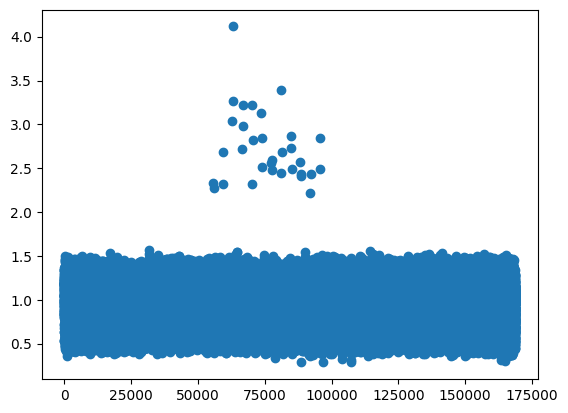

In [60]:
import matplotlib.pyplot as plt
plt.figure()
plt.plot(np.ravel(np.log10(max_outliers)),'o')
plt.show()

In [32]:
compute_mean_tsnr(bold_filenames, out_file=os.path.join(out_root, "tsnr_volume.nii.gz"))

/juice6/u/nlp/climblab/BIDS/nptl/derivatives/preprocess/main/sub-t20/ses-ex31792/func/sub-t20_ses-ex31792_task-Rest_run-01_space-T1w_desc-preproc_bold.nii.gz
/juice6/u/nlp/climblab/BIDS/nptl/derivatives/preprocess/main/sub-t20/ses-ex31792/func/sub-t20_ses-ex31792_task-Rest_run-02_space-T1w_desc-preproc_bold.nii.gz
/juice6/u/nlp/climblab/BIDS/nptl/derivatives/preprocess/main/sub-t20/ses-ex31792/func/sub-t20_ses-ex31792_task-Rest_run-03_space-T1w_desc-preproc_bold.nii.gz
/juice6/u/nlp/climblab/BIDS/nptl/derivatives/preprocess/main/sub-t20/ses-ex31792/func/sub-t20_ses-ex31792_task-UnknownTask_run-01_space-T1w_desc-preproc_bold.nii.gz
/juice6/u/nlp/climblab/BIDS/nptl/derivatives/preprocess/main/sub-t20/ses-ex31793/func/sub-t20_ses-ex31793_task-Rest_run-01_space-T1w_desc-preproc_bold.nii.gz
/juice6/u/nlp/climblab/BIDS/nptl/derivatives/preprocess/main/sub-t20/ses-ex31793/func/sub-t20_ses-ex31793_task-langlocSN_run-01_space-T1w_desc-preproc_bold.nii.gz
/juice6/u/nlp/climblab/BIDS/nptl/derivat

'/juice6/u/nlp/climblab/BIDS/nptl/derivatives/seed_from_ica_spatialclean/regressors/node-subject/sub-t20/tsnr_volume.nii.gz'

In [33]:
#project raw bold onto the surface
anat_path = get_preprocessed_anat_dir(project, participant, preprocessing_label='main')

if os.path.basename(os.path.dirname(anat_path)).startswith('ses-'):
    ses_str_anat = f'_ses-{os.path.basename(os.path.dirname(anat_path))[4:]}'
else:
    ses_str_anat = ''

LWHITE = os.path.join(anat_path, f"sub-{participant}{ses_str_anat}_hemi-L_white.surf.gii")
LPIAL  = os.path.join(anat_path, f"sub-{participant}{ses_str_anat}_hemi-L_pial.surf.gii")
LMID   = os.path.join(anat_path, f"sub-{participant}{ses_str_anat}_hemi-L_midthickness.surf.gii")
RWHITE = os.path.join(anat_path, f"sub-{participant}{ses_str_anat}_hemi-R_white.surf.gii")
RPIAL  = os.path.join(anat_path, f"sub-{participant}{ses_str_anat}_hemi-R_pial.surf.gii")
RMID   = os.path.join(anat_path, f"sub-{participant}{ses_str_anat}_hemi-R_midthickness.surf.gii")

# One mapping per hemisphere -> multi-map metrics (one map per IC)
LMET = os.path.join(out_root, "tsnr_volume.L.func.gii")
RMET = os.path.join(out_root, "tsnr_volume.R.func.gii")

denoised = os.path.join(out_root, "tsnr_volume.nii.gz")
print(denoised)

container = '/juice6/u/nlp/climblab/apptainer/images/qunex_suite-1.4.0.sif'
bind = '/juice6:/juice6'

# Map 4D volume -> multi-map metric
cx(container, home_dir, bind,
   f"wb_command -volume-to-surface-mapping {_shlex(denoised)} {_shlex(LMID)} {_shlex(LMET)} "
   f"-ribbon-constrained {_shlex(LWHITE)} {_shlex(LPIAL)}")
cx(container, home_dir, bind,
   f"wb_command -volume-to-surface-mapping {_shlex(denoised)} {_shlex(RMID)} {_shlex(RMET)} "
   f"-ribbon-constrained {_shlex(RWHITE)} {_shlex(RPIAL)}")

# Create a single multi-map dscalar from the two multi-map metrics
DS = os.path.join(out_root, "tsnr_volume.dtseries.nii")
cx(container, home_dir, bind,
   f"wb_command -cifti-create-dense-timeseries {_shlex(DS)} -left-metric {_shlex(LMET)} -right-metric {_shlex(RMET)} -timestep {TR} -timestart 0")


/juice6/u/nlp/climblab/BIDS/nptl/derivatives/seed_from_ica_spatialclean/regressors/node-subject/sub-t20/tsnr_volume.nii.gz


singularity exec --cleanenv -H '/juice6/u/nlp/climblab/BIDS/nptl/derivatives/seed_from_ica_spatialclean/regressors/node-subject/sub-t20/_qunex_home' -B /juice6:/juice6 '/juice6/u/nlp/climblab/apptainer/images/qunex_suite-1.4.0.sif' bash -lc 'wb_command -volume-to-surface-mapping '\''/juice6/u/nlp/climblab/BIDS/nptl/derivatives/seed_from_ica_spatialclean/regressors/node-subject/sub-t20/tsnr_volume.nii.gz'\'' '\''/juice6/u/nlp/climblab/BIDS/nptl/derivatives/preprocess/main/sub-t20/ses-ex31792/anat/sub-t20_ses-ex31792_hemi-L_midthickness.surf.gii'\'' '\''/juice6/u/nlp/climblab/BIDS/nptl/derivatives/seed_from_ica_spatialclean/regressors/node-subject/sub-t20/tsnr_volume.L.func.gii'\'' -ribbon-constrained '\''/juice6/u/nlp/climblab/BIDS/nptl/derivatives/preprocess/main/sub-t20/ses-ex31792/anat/sub-t20_ses-ex31792_hemi-L_white.surf.gii'\'' '\''/juice6/u/nlp/climblab/BIDS/nptl/derivatives/preprocess/main/sub-t20/ses-ex31792/anat/sub-t20_ses-ex31792_hemi-L_pial.surf.gii'\'''




Generated by QuNex
------------------------------------------------------------------------
Version: 1.4.0 [QIO]
User: fwillett
System: john2.stanford.edu
OS: Debian Linux #119-Ubuntu SMP Mon Mar 7 18:49:24 UTC 2022
------------------------------------------------------------------------


        ██████\                 ║     ██\   ██\                       
       ██  __██\                ║     ███\  ██ |                      
       ██ /  ██ |██\   ██\      ║     ████\ ██ | ██████\ ██\   ██\    
       ██ |  ██ |██ |  ██ |     ║     ██ ██\██ |██  __██\\██\ ██  |
       ██ |  ██ |██ |  ██ |     ║     ██ \████ |████████ |\████  /    
       ██ ██\██ |██ |  ██ |     ║     ██ |\███ |██   ____|██  ██\     
       \██████ / \██████  |     ║     ██ | \██ |\███████\██  /\██\    
        \___███\  \______/      ║     \__|  \__| \_______\__/  \__|   
            \___|               ║                                     


                            1.4.0 [QIO]

                      DEVELOP

singularity exec --cleanenv -H '/juice6/u/nlp/climblab/BIDS/nptl/derivatives/seed_from_ica_spatialclean/regressors/node-subject/sub-t20/_qunex_home' -B /juice6:/juice6 '/juice6/u/nlp/climblab/apptainer/images/qunex_suite-1.4.0.sif' bash -lc 'wb_command -volume-to-surface-mapping '\''/juice6/u/nlp/climblab/BIDS/nptl/derivatives/seed_from_ica_spatialclean/regressors/node-subject/sub-t20/tsnr_volume.nii.gz'\'' '\''/juice6/u/nlp/climblab/BIDS/nptl/derivatives/preprocess/main/sub-t20/ses-ex31792/anat/sub-t20_ses-ex31792_hemi-R_midthickness.surf.gii'\'' '\''/juice6/u/nlp/climblab/BIDS/nptl/derivatives/seed_from_ica_spatialclean/regressors/node-subject/sub-t20/tsnr_volume.R.func.gii'\'' -ribbon-constrained '\''/juice6/u/nlp/climblab/BIDS/nptl/derivatives/preprocess/main/sub-t20/ses-ex31792/anat/sub-t20_ses-ex31792_hemi-R_white.surf.gii'\'' '\''/juice6/u/nlp/climblab/BIDS/nptl/derivatives/preprocess/main/sub-t20/ses-ex31792/anat/sub-t20_ses-ex31792_hemi-R_pial.surf.gii'\'''




Generated by QuNex
------------------------------------------------------------------------
Version: 1.4.0 [QIO]
User: fwillett
System: john2.stanford.edu
OS: Debian Linux #119-Ubuntu SMP Mon Mar 7 18:49:24 UTC 2022
------------------------------------------------------------------------


        ██████\                 ║     ██\   ██\                       
       ██  __██\                ║     ███\  ██ |                      
       ██ /  ██ |██\   ██\      ║     ████\ ██ | ██████\ ██\   ██\    
       ██ |  ██ |██ |  ██ |     ║     ██ ██\██ |██  __██\\██\ ██  |
       ██ |  ██ |██ |  ██ |     ║     ██ \████ |████████ |\████  /    
       ██ ██\██ |██ |  ██ |     ║     ██ |\███ |██   ____|██  ██\     
       \██████ / \██████  |     ║     ██ | \██ |\███████\██  /\██\    
        \___███\  \______/      ║     \__|  \__| \_______\__/  \__|   
            \___|               ║                                     


                            1.4.0 [QIO]

                      DEVELOP

singularity exec --cleanenv -H '/juice6/u/nlp/climblab/BIDS/nptl/derivatives/seed_from_ica_spatialclean/regressors/node-subject/sub-t20/_qunex_home' -B /juice6:/juice6 '/juice6/u/nlp/climblab/apptainer/images/qunex_suite-1.4.0.sif' bash -lc 'wb_command -cifti-create-dense-timeseries '\''/juice6/u/nlp/climblab/BIDS/nptl/derivatives/seed_from_ica_spatialclean/regressors/node-subject/sub-t20/tsnr_volume.dtseries.nii'\'' -left-metric '\''/juice6/u/nlp/climblab/BIDS/nptl/derivatives/seed_from_ica_spatialclean/regressors/node-subject/sub-t20/tsnr_volume.L.func.gii'\'' -right-metric '\''/juice6/u/nlp/climblab/BIDS/nptl/derivatives/seed_from_ica_spatialclean/regressors/node-subject/sub-t20/tsnr_volume.R.func.gii'\'' -timestep 1.08 -timestart 0'




Generated by QuNex
------------------------------------------------------------------------
Version: 1.4.0 [QIO]
User: fwillett
System: john2.stanford.edu
OS: Debian Linux #119-Ubuntu SMP Mon Mar 7 18:49:24 UTC 2022
------------------------------------------------------------------------


        ██████\                 ║     ██\   ██\                       
       ██  __██\                ║     ███\  ██ |                      
       ██ /  ██ |██\   ██\      ║     ████\ ██ | ██████\ ██\   ██\    
       ██ |  ██ |██ |  ██ |     ║     ██ ██\██ |██  __██\\██\ ██  |
       ██ |  ██ |██ |  ██ |     ║     ██ \████ |████████ |\████  /    
       ██ ██\██ |██ |  ██ |     ║     ██ |\███ |██   ____|██  ██\     
       \██████ / \██████  |     ║     ██ | \██ |\███████\██  /\██\    
        \___███\  \______/      ║     \__|  \__| \_______\__/  \__|   
            \___|               ║                                     


                            1.4.0 [QIO]

                      DEVELOP